<a href="https://colab.research.google.com/github/Bhoomika685/Hypersonic-Vehicle/blob/main/Hypersonic_vehicle_guidance_and_control_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hypersonic Vehicle Guidance and Control Simulation

Project Overview

This project simulates the flight dynamics and guidance control of a hypersonic vehicle traveling at very high speeds (greater than Mach 5). Hypersonic vehicles experience extreme aerodynamic forces and heating, making their control and stability challenging.

Physics Model and Assumptions
The key state variables modeled in this simulation are:

Velocity (v): the speed of the vehicle relative to the atmosphere, in meters per second.

Flight path angle (γ): the angle between the vehicle’s velocity vector and the local horizontal plane.

Altitude (h): the height above sea level, in meters.

Skin temperature: temperature of the vehicle’s outer surface due to aerodynamic heating, in Kelvin.

The vehicle's dynamics are influenced by several forces:

Gravity: constant downward acceleration of 9.81 m/s².

Aerodynamic Drag (D): resistive force opposing motion, dependent on velocity squared, air density, drag coefficient, and reference area.

Aerodynamic Lift (L): upward force perpendicular to velocity vector, affected by velocity squared, air density, lift coefficient, and reference area.

Drag and lift coefficients vary with flight path angle to capture simple nonlinear aerodynamic effects.

Aerodynamic Heating Model
Hypersonic vehicles fly through very dense and hot air at high speed, generating strong surface heating. This simulation includes a simple aerodynamic heating model where heat flux scales with velocity cubed and atmospheric density, with skin temperature evolving accordingly.

Control System: PID Feedback
A PID (Proportional-Integral-Derivative) controller regulates the flight path angle to maintain the vehicle near a desired altitude. The altitude error—the difference between desired and current altitude—is processed by the PID controller to compute changes in flight path angle to correct the vehicle’s trajectory.

Simulation Workflow
The system’s ordinary differential equations are defined and integrated over time using solve_ivp.

At each time step, the PID controller computes the wing adjustment necessary to maintain the target altitude.

Aerodynamic forces and heating update the state variables.

Simulation outputs state trajectories for velocity, flight path angle, altitude, and skin temperature.

The data is saved to a CSV file for subsequent analysis and visualization in MATLAB.

Goals and Deliverables
To demonstrate understanding of flight dynamics under hypersonic conditions.

To design and implement a feedback control algorithm (PID) for trajectory guidance.

To model aerodynamic heating and observe its impact on vehicle skin temperature.

To learn the workflow of combining Python simulation and MATLAB analysis seamlessly.

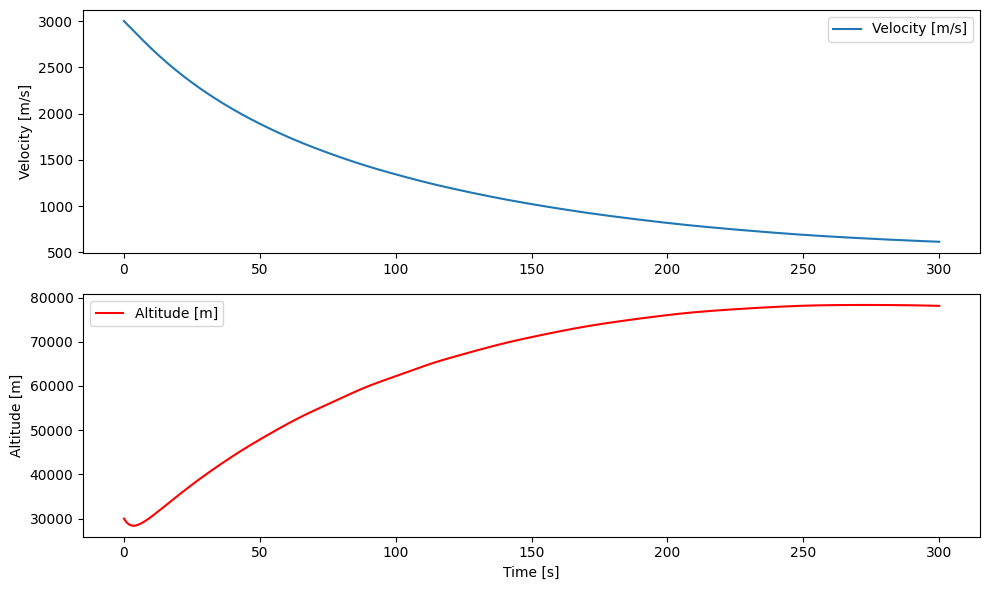

In [ ]:
# --- Step 1: Import Libraries ---
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- Step 2: Define Physics Model ---
def hypersonic_dynamics(t, s, gamma_command):
    v, gamma, h = s
    g = 9.81                  # gravity [m/s^2]
    rho = 0.018               # air density at high altitude [kg/m^3]
    Cd, Cl = 0.2, 1.2         # drag, lift coefficients
    A, m = 2, 1000            # ref. area [m^2], mass [kg]

    # --- Control action: feedback to gamma (flight path angle) ---
    # Real controller compares current h to desired h, outputs gamma_command
    gamma = gamma_command   # substitute for closed-loop control logic

    D = 0.5 * rho * v**2 * Cd * A  # Drag force [N]
    L = 0.5 * rho * v**2 * Cl * A  # Lift force [N]

    # --- Equations of motion ---
    dvdt = -D/m - g*np.sin(gamma)                    # Velocity rate
    dgammadt = (L / (m*v)) - (g*np.cos(gamma)/v)     # Flight path angle rate
    dhdt = v * np.sin(gamma)                         # Altitude rate

    return [dvdt, dgammadt, dhdt]

# --- Step 3: Command Logic and Initial State ---
# You can make gamma_command a function of time for step/guidance changes:
def gamma_control(t, s, h_desired=28000):
    v, gamma, h = s
    # Simple feedback: correct gamma to reduce altitude error
    error = h_desired - h
    Kp = 0.0001       # Feedback gain, tune as needed
    gamma_cmd = gamma + Kp * error
    return gamma_cmd

# Initial Conditions
v0 = 3000                # initial velocity [m/s]
gamma0 = -10*np.pi/180   # initial flight path angle [rad]
h0 = 30000               # initial altitude [m]
s0 = [v0, gamma0, h0]
t_span = [0, 300]  # simulate for 300 seconds

# --- Step 4: Simulate ---
def wrapped_dyn(t, y):
    gamma_cmd = gamma_control(t, y)
    return hypersonic_dynamics(t, y, gamma_cmd)

sol = solve_ivp(wrapped_dyn, t_span, s0, t_eval=np.linspace(0, 300, 301))

# --- Step 5: Save Simulation Results ---
data = np.vstack((sol.t, sol.y)).T
np.savetxt("hypersonic_results.csv", data, delimiter=",", header="time,velocity,gamma,altitude", comments='')

# --- Step 6: Plot Velocity, Altitude, and Control Profile ---
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(sol.t, sol.y[0], label='Velocity [m/s]')
plt.ylabel('Velocity [m/s]')
plt.legend()
plt.subplot(2,1,2)
plt.plot(sol.t, sol.y[2], label='Altitude [m]', color='r')
plt.xlabel('Time [s]')
plt.ylabel('Altitude [m]')
plt.legend()
plt.tight_layout()
plt.savefig("hypersonic_plot.png")
plt.show()

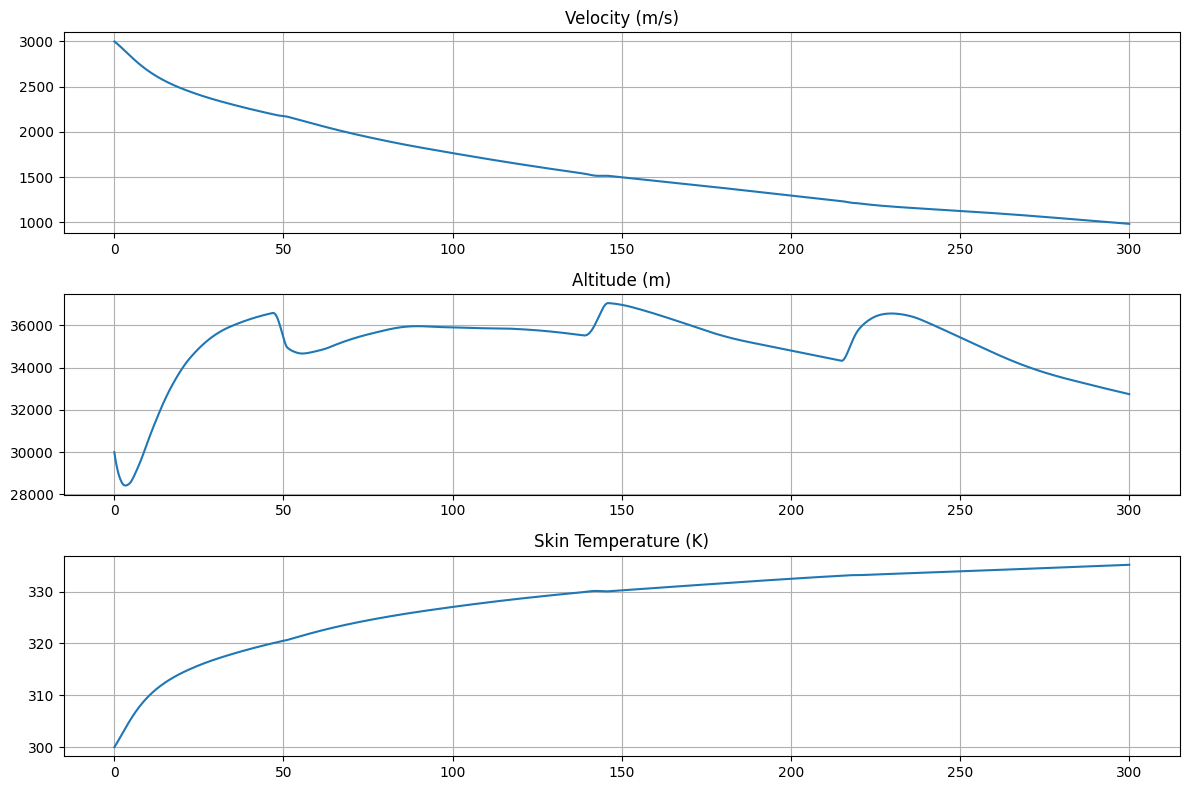

In [ ]:
# Hypersonic Vehicle Guidance & Control Simulation with PID and Aero Heating

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# PID Controller Class
class PIDController:
    def __init__(self, Kp, Ki, Kd):
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.integral = 0
        self.prev_error = 0
    def update(self, error, dt):
        self.integral += error * dt
        derivative = (error - self.prev_error) / dt if dt > 0 else 0
        self.prev_error = error
        return self.Kp * error + self.Ki * self.integral + self.Kd * derivative

# Aerodynamic Heating Model
def aero_heating(v, h):
    rho0 = 1.225  # sea level density
    H = 7000      # scale height [m]
    rho = rho0 * np.exp(-h / H)  # exponential atmosphere model
    q_dot = 1e-4 * rho * v**3    # heat flux (arbitrary scaling)
    return q_dot

# Hypersonic Vehicle Dynamics with PID Control & Heating
def hypersonic_dynamics(t, s, controller, desired_altitude, dt):
    v, gamma, h, T_skin = s
    g = 9.81
    A, m = 2, 1000
    Cd0, Cl0 = 0.2, 1.2         # nominal aerodynamic coeff.
    # Simple variable aero coeff. based on gamma - realistic enhancements possible
    Cd = Cd0 + 0.05 * np.abs(gamma)
    Cl = Cl0 - 0.1 * np.abs(gamma)

    # PID control: feedback on altitude error, modifies flight path angle gamma
    error = desired_altitude - h
    delta_gamma = controller.update(error, dt)
    gamma_cmd = gamma + delta_gamma

    # Compute aerodynamic forces
    rho0 = 1.225
    H = 7000
    rho = rho0 * np.exp(-h / H)
    D = 0.5 * rho * v**2 * Cd * A
    L = 0.5 * rho * v**2 * Cl * A

    # Equations of motion
    dvdt = -D / m - g * np.sin(gamma_cmd)
    dgammadt = (L / (m * v)) - (g * np.cos(gamma_cmd)) / v
    dhdt = v * np.sin(gamma_cmd)

    # Aerodynamic heating and skin temperature dynamics
    q_dot = aero_heating(v, h)
    c_p = 900    # specific heat capacity [J/kg*K], approximate for metals
    mass_skin = 50    # assume 50 kg for skin mass
    dT_skin_dt = q_dot / (mass_skin * c_p)

    return [dvdt, dgammadt, dhdt, dT_skin_dt]

# Initial conditions and simulation parameters
v0 = 3000
gamma0 = -10 * np.pi / 180  # radians
h0 = 30000                  # meters
T_skin0 = 300               # initial skin temp (K)
desired_altitude = 28000    # target altitude for guidance feedback
s0 = [v0, gamma0, h0, T_skin0]

controller = PIDController(Kp=1e-4, Ki=1e-6, Kd=1e-5)
t_start, t_end = 0, 300
dt = 0.1
t_eval = np.arange(t_start, t_end + dt, dt)

# Wrapper to pass controller and compute time step for PID
def ode_func(t, s):
    if t == t_start:
        dt_used = dt
    else:
        dt_used = t - ode_func.prev_t
    ode_func.prev_t = t
    return hypersonic_dynamics(t, s, controller, desired_altitude, dt_used)
ode_func.prev_t = t_start

# Solve ODE
sol = solve_ivp(ode_func, [t_start, t_end], s0, t_eval=t_eval, method='RK45')

# Extract results
v = sol.y[0]
gamma = sol.y[1]
h = sol.y[2]
T_skin = sol.y[3]
t = sol.t

# Save CSV data for MATLAB Online
data = np.vstack((t, v, gamma, h, T_skin)).T
np.savetxt('hypersonic_pid_heating_results.csv', data,
           delimiter=',',
           header='time,v, gamma, altitude, skin_temp',
           comments='')

# Plot results
plt.figure(figsize=(12, 8))

plt.subplot(3,1,1)
plt.plot(t, v)
plt.title('Velocity (m/s)')
plt.grid()

plt.subplot(3,1,2)
plt.plot(t, h)
plt.title('Altitude (m)')
plt.grid()

plt.subplot(3,1,3)
plt.plot(t, T_skin)
plt.title('Skin Temperature (K)')
plt.grid()

plt.tight_layout()
plt.savefig('hypersonic_advanced_results.png')
plt.show()